In [1]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

!git clone https://github.com/yazeedsn/SSL_SimCLR_Experiment.git
%cd SSL_SimCLR_Experiment
!pip install -r requirements.txt
!pip install -e .

Cloning into 'SSL_SimCLR_Experiment'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 76 (delta 36), reused 61 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 1.46 MiB | 10.75 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/kaggle/working/SSL_SimCLR_Experiment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 83.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 21.6 MB/s eta 0:00:00
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2026.1
    Uninstalling tzdata-2026.1:
      Successfully uninstalled tzdata-2026.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Success

In [2]:
import torch
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torch.optim import AdamW

from src.models import SimCLR
from src.eval import evaluate_linear_probe
from src.train import train_linear_probe
from src.utils import plot_metric, save_model
from src.datasets import get_labeled_ds, get_eval_ds
from src.transforms import get_random_augmentation_normalized_transform, get_random_augmentation_transform

# Training Baseline Model For Linear Probing

In [3]:
# Create a linear probing model with forzen backbone, only train linear probing layers.
random_resnet18 = SimCLR()
random_resnet18.unfreeze_encoder()
random_resnet18 = random_resnet18.get_linear_prob(10)

# get the labeled dataset
labeled_ds = get_labeled_ds()
labeled_dl = DataLoader(labeled_ds, batch_size=512, shuffle=True)

# create an optimizer factory, only trains unfrozen parameters
optimizer_factory = lambda p : AdamW(p, lr=1e-3)

# cross entropy loss
loss_fn = CrossEntropyLoss()

# configs
device = 'cuda' if torch.cuda.is_available() else 'cpu'
random_resnet18= random_resnet18.to(device)
n_epochs = 200

# training function
loss_hist_baseline, acc_hist_baseline = train_linear_probe(
    random_resnet18,
    labeled_dl,
    optimizer_factory,
    loss_fn,
    device,
    n_epochs
)

100%|██████████| 2.64G/2.64G [06:58<00:00, 6.30MB/s] 
Epoch [1/200] Batch [10/10]: 100%|██████████| 10/10 [00:18<00:00,  1.90s/it, Loss=1.8536]



Epoch 1 completed — Avg Loss: 2.1522 | Avg Acc: 0.2238



Epoch [2/200] Batch [10/10]: 100%|██████████| 10/10 [00:17<00:00,  1.72s/it, Loss=1.6765]



Epoch 2 completed — Avg Loss: 1.7395 | Avg Acc: 0.3298



Epoch [3/200] Batch [10/10]: 100%|██████████| 10/10 [00:17<00:00,  1.72s/it, Loss=1.5815]


...


Epoch 198 completed — Avg Loss: 0.1521 | Avg Acc: 0.9468



Epoch [199/200] Batch [10/10]: 100%|██████████| 10/10 [00:17<00:00,  1.72s/it, Loss=0.1897]



Epoch 199 completed — Avg Loss: 0.1443 | Avg Acc: 0.9534



Epoch [200/200] Batch [10/10]: 100%|██████████| 10/10 [00:17<00:00,  1.71s/it, Loss=0.1396]


Epoch 200 completed — Avg Loss: 0.1283 | Avg Acc: 0.9582



In [4]:
save_model(random_resnet18, 'random_resnet18')

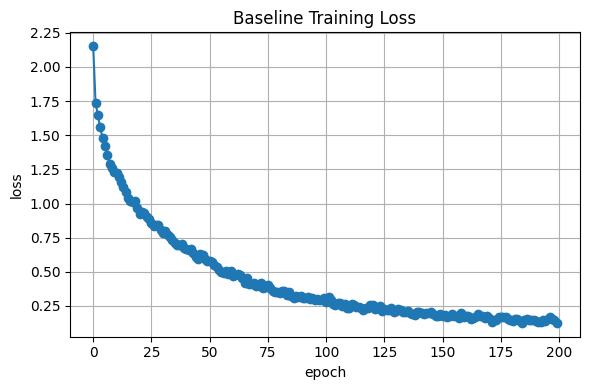

In [5]:
plot_metric(
    loss_hist_baseline,
    list(range(n_epochs)),
    ylabel='loss',
    xlabel='epoch',
    title='Baseline Training Loss',
    save_path='outputs/baseline_loss_curve.png'
)

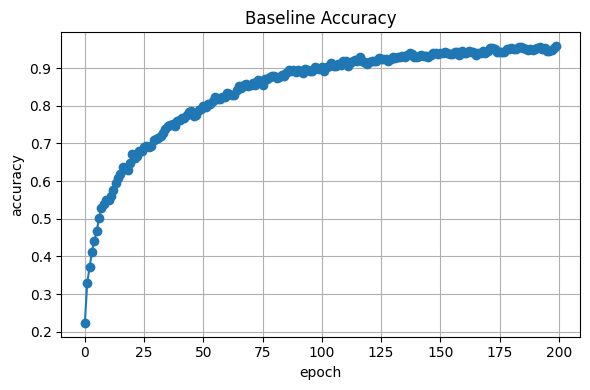

In [6]:
# plot accuracy
plot_metric(
    acc_hist_baseline,
    list(range(n_epochs)),
    ylabel='accuracy',
    xlabel='epoch',
    title='Baseline Accuracy',
    save_path='outputs/baseline_acc_curve.png'
)

In [7]:
# get evaluation dataset
eval_ds = get_eval_ds()
eval_dl = DataLoader(eval_ds, batch_size=512, shuffle=False)

eval_acc_baseline = evaluate_linear_probe(random_resnet18, eval_dl, len(eval_ds), device)

Test Accuracy: 0.7101
